In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 

In [2]:
# load data
data_path1 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-04-city-of-london-street.csv"
data_path2 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-05-city-of-london-street.csv"
data_path3 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-06-city-of-london-street.csv"
data_path4 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-07-city-of-london-street.csv"
data_path5 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-08-city-of-london-street.csv"
data_path6 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-09-city-of-london-street.csv"
data_path7 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-10-city-of-london-street.csv"
data_path8 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-11-city-of-london-street.csv"
data_path9 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-12-city-of-london-street.csv"
data_path10 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2026-01-city-of-london-street.csv"
data_path11 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2026-02-city-of-london-street.csv"
data_path12 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2026-03-city-of-london-street.csv"
data1 = pd.read_csv(data_path1)
data2 = pd.read_csv(data_path2)
data3 = pd.read_csv(data_path3)
data4 = pd.read_csv(data_path4)
data5 = pd.read_csv(data_path5)
data6 = pd.read_csv(data_path6)
data7 = pd.read_csv(data_path7)
data8 = pd.read_csv(data_path8)
data9 = pd.read_csv(data_path9)
data10 = pd.read_csv(data_path10)
data11 = pd.read_csv(data_path11)
data12 = pd.read_csv(data_path12)

In [3]:
allData = [data1, data2, data3, data4, data5, data6, data7, data8, data9, data10, data11, data12]

data = pd.concat(allData, ignore_index=True)
data = data.drop(columns=['Context', 'LSOA code'])
# since the point of this is investigating the crime types per LSOA, the crimes that are missing either or both of these parameters will be dropped
data = data.dropna(subset=["LSOA name", "Crime type"])

In [4]:
crimeTypes = pd.unique(data['Crime type']).tolist()

## Correlation between crime types

We begin by looking in one area to determine the correlation coefficient within all crime type pairs.

In [5]:
# a function that returns a list of counts for a crime type for each month in the given dataframe

def get_crime_count(crime_type, area, timeColumn: str) -> list:
    '''
    Given an area and a crime type, the function returns a list of crime counts for each month given.
    '''
    filteredData = data[(data['LSOA name'] == area) & (data['Crime type'] == crime_type)]
    all_months = sorted(data[timeColumn].unique())
    crimeCount = filteredData[timeColumn].value_counts()
    crimeCount = crimeCount.reindex(all_months, fill_value=0)
    
    return list(crimeCount)

get_crime_count('Robbery', 'City of London 001B', 'Month')

[2, 0, 0, 0, 1, 1, 0, 0, 2, 0, 0, 2]

In [6]:
crime_counts_per_area = {
    crime_type : get_crime_count(crime_type, 'City of London 001B', 'Month') for crime_type in crimeTypes
}

crime_counts_per_area

{'Other theft': [9, 8, 4, 4, 5, 7, 10, 7, 3, 7, 7, 7],
 'Robbery': [2, 0, 0, 0, 1, 1, 0, 0, 2, 0, 0, 2],
 'Theft from the person': [5, 4, 2, 2, 2, 1, 2, 1, 2, 0, 0, 2],
 'Anti-social behaviour': [0, 2, 1, 1, 1, 0, 0, 1, 0, 0, 1, 3],
 'Burglary': [0, 2, 1, 0, 0, 0, 1, 2, 1, 0, 0, 0],
 'Public order': [2, 4, 2, 4, 2, 0, 3, 3, 1, 4, 1, 7],
 'Shoplifting': [8, 7, 13, 21, 12, 15, 1, 4, 13, 6, 6, 19],
 'Bicycle theft': [4, 7, 5, 5, 3, 5, 12, 9, 6, 4, 1, 2],
 'Criminal damage and arson': [2, 4, 0, 1, 0, 0, 2, 0, 1, 3, 2, 3],
 'Other crime': [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'Violence and sexual offences': [0, 3, 4, 6, 1, 3, 2, 2, 4, 2, 0, 2],
 'Drugs': [0, 0, 1, 1, 1, 0, 0, 0, 2, 6, 13, 3],
 'Vehicle crime': [0, 1, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0],
 'Possession of weapons': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}

In [7]:
crimeDataFrame = pd.DataFrame(crime_counts_per_area, columns=crimeTypes)
crimeDataFrame

,Other theft,Robbery,Theft from the person,Anti-social behaviour,Burglary,Public order,Shoplifting,Bicycle theft,Criminal damage and arson,Other crime,Violence and sexual offences,Drugs,Vehicle crime,Possession of weapons
0,9,2,5,0,0,2,8,4,2,1,0,0,0,0
1,8,0,4,2,2,4,7,7,4,1,3,0,1,0
2,4,0,2,1,1,2,13,5,0,0,4,1,0,0
3,4,0,2,1,0,4,21,5,1,0,6,1,0,0
4,5,1,2,1,0,2,12,3,0,0,1,1,1,0
5,7,1,1,0,0,0,15,5,0,0,3,0,0,0
6,10,0,2,0,1,3,1,12,2,0,2,0,2,0
7,7,0,1,1,2,3,4,9,0,0,2,0,0,0
8,3,2,2,0,1,1,13,6,1,0,4,2,0,0
9,7,0,0,0,0,4,6,4,3,0,2,6,0,0


In [8]:
corrMatrix = crimeDataFrame.corr()
corrMatrix

,Other theft,Robbery,Theft from the person,Anti-social behaviour,Burglary,Public order,Shoplifting,Bicycle theft,Criminal damage and arson,Other crime,Violence and sexual offences,Drugs,Vehicle crime,Possession of weapons
Other theft,1.000000,-0.097052,0.223814,-0.045948,0.081479,0.173240,-0.632277,0.321028,0.498784,0.442627,-0.610043,-0.028213,0.462910,NaN
Robbery,-0.097052,1.000000,0.402092,0.036418,-0.344425,0.000000,0.397552,-0.339259,0.000000,0.175412,-0.197353,-0.187833,-0.262071,NaN
Theft from the person,0.223814,0.402092,1.000000,0.123176,0.205190,0.126660,0.055955,0.151259,0.250713,0.836008,-0.021239,-0.589931,0.225630,NaN
Anti-social behaviour,-0.045948,0.036418,0.123176,1.000000,0.142679,0.702069,0.363173,-0.305171,0.350931,0.083045,0.046717,0.063519,-0.049629,NaN
Burglary,0.081479,-0.344425,0.205190,0.142679,1.000000,0.046110,-0.449712,0.693062,0.041487,0.245440,0.204345,-0.382968,0.293357,NaN
Public order,0.173240,0.000000,0.126660,0.702069,0.046110,1.000000,0.201896,-0.020186,0.582182,0.062622,0.119775,-0.079830,0.074848,NaN
Shoplifting,-0.632277,0.397552,0.055955,0.363173,-0.449712,0.201896,1.000000,-0.495136,-0.221221,-0.223447,0.568159,-0.149422,-0.473096,NaN
Bicycle theft,0.321028,-0.339259,0.151259,-0.305171,0.693062,-0.020186,-0.495136,1.000000,-0.076281,0.038682,0.256769,-0.581863,0.601032,NaN
Criminal damage and arson,0.498784,0.000000,0.250713,0.350931,0.041487,0.582182,-0.221221,-0.076281,1.000000,0.507093,-0.209192,0.267192,0.202031,NaN
Other crime,0.442627,0.175412,0.836008,0.083045,0.245440,0.062622,-0.223447,0.038682,0.507093,1.000000,-0.247519,-0.275353,0.119523,NaN


### some analysis 
- perfect if 1 < |r| < 0.9
- strong if 0.9 < |r| < 0.5
- weak if 0.5 < |r| < 0.1
- uncorrelated if 0.1 < |r| < 0

Note. any correlation above 0.3 / below -0.3 is considered significant

In [9]:
edge_list = corrMatrix.stack().reset_index()
edge_list.columns = ['Crime 1', 'Crime 2', 'Correlation']
strong_edges = edge_list[(edge_list['Correlation'] >= 0.3) & (edge_list['Correlation'] < 1.0)]


strong_edges = strong_edges.sort_values(by='Correlation', ascending=False)
print("Here are the strongest bridges:")
print(strong_edges)

Here are the strongest bridges:
                          Crime 1                       Crime 2  Correlation
35          Theft from the person                   Other crime     0.836008
119                   Other crime         Theft from the person     0.836008
68                   Public order         Anti-social behaviour     0.702069
44          Anti-social behaviour                  Public order     0.702069
95                  Bicycle theft                      Burglary     0.693062
59                       Burglary                 Bicycle theft     0.693062
103                 Bicycle theft                 Vehicle crime     0.601032
163                 Vehicle crime                 Bicycle theft     0.601032
73                   Public order     Criminal damage and arson     0.582182
109     Criminal damage and arson                  Public order     0.582182
136  Violence and sexual offences                   Shoplifting     0.568159
88                    Shoplifting  Violence 

In [10]:
# this we use for co-occurence analysis, thats why we only use positive correlation

Furthermore, we will investigate if certain "Brokerage Crimes" act as leading indicators for more severe crimes in the following month.
For that, we need to check the co-occurrence within consecutive months.

In [11]:
# Each row now contains the data from the previous month
shifted_df = crimeDataFrame.shift(1)

# Rename columns to keep track of the "Lead" and "Lag"
shifted_df.columns = [f"{c}_prevM" for c in crimeTypes]

# put them side-by-side and drop the first row because no data before month 1
combined_df = pd.concat([crimeDataFrame, shifted_df], axis=1).dropna()


In [12]:
# correlate the current month with the previous month
lagged_corr = combined_df.corr()

# Filter for correlations only current crimes and last month's crimes
# This finds if 'Theft_LastMonth' predicts 'Burglary' this month
lead_lag_edges = lagged_corr.loc[crimeTypes, [f"{c}_prevM" for c in crimeTypes]]

lead_lag_edges

,Other theft_prevM,Robbery_prevM,Theft from the person_prevM,Anti-social behaviour_prevM,Burglary_prevM,Public order_prevM,Shoplifting_prevM,Bicycle theft_prevM,Criminal damage and arson_prevM,Other crime_prevM,Violence and sexual offences_prevM,Drugs_prevM,Vehicle crime_prevM,Possession of weapons_prevM
Other theft,0.212552,0.555856,-0.087733,-0.715620,-0.716714,-0.611060,0.102707,-0.304628,-0.039004,-0.065653,-0.332758,0.151775,-0.006565,NaN
Robbery,-0.095402,-0.337838,-0.439375,0.394558,0.027400,-0.016278,-0.102486,-0.215818,-0.284864,-0.328798,-0.251198,0.454952,-0.213719,NaN
Theft from the person,0.356656,0.128644,0.568416,0.204656,-0.050161,-0.101320,0.055224,-0.144415,-0.035760,0.601929,-0.255731,-0.184859,-0.204656,NaN
Anti-social behaviour,0.357782,-0.187885,0.063634,0.100000,-0.309524,0.028290,-0.265491,-0.407411,0.495074,0.309524,-0.441890,0.667736,-0.100000,NaN
Burglary,0.829734,0.178099,0.541946,-0.266667,0.236111,0.041256,-0.505777,0.588482,0.222783,0.527778,-0.354044,-0.472477,0.450000,NaN
Public order,0.044580,0.131405,-0.040248,-0.132059,-0.173762,-0.540237,-0.060498,-0.292609,0.103230,0.046337,-0.202043,0.559443,-0.250217,NaN
Shoplifting,-0.358305,-0.419268,-0.066266,0.737464,0.166478,0.109424,0.064744,-0.374722,-0.133624,-0.049589,-0.036434,0.346068,-0.153018,NaN
Bicycle theft,0.406691,0.264808,0.260210,-0.309266,0.096646,-0.431684,-0.036377,0.457911,-0.338117,0.100225,-0.049624,-0.603765,0.309266,NaN
Criminal damage and arson,0.054351,0.615895,0.020859,-0.533854,-0.359025,-0.551778,-0.074911,-0.460010,0.060278,0.187317,-0.432816,0.401425,-0.599415,NaN
Other crime,0.382451,0.588172,0.677296,-0.313050,-0.260875,-0.088561,-0.094684,-0.172077,0.154983,0.670820,-0.450000,-0.181113,-0.178885,NaN


In [13]:
edgeList = lead_lag_edges.stack().reset_index()
edgeList.columns = ['Crime 1', 'Crime 2', 'Correlation']
strongEdges = edgeList[(edgeList['Correlation'] >= 0.3) & (edgeList['Correlation'] < 1.0)]


strongEdges = strongEdges.sort_values(by='Correlation', ascending=False)
print("Here are the strongest bridges:")
print(strongEdges.head(20))

Here are the strongest bridges:
                          Crime 1                          Crime 2  \
52                       Burglary                Other theft_prevM   
81                    Shoplifting      Anti-social behaviour_prevM   
119                   Other crime      Theft from the person_prevM   
126                   Other crime                Other crime_prevM   
50          Anti-social behaviour                      Drugs_prevM   
105     Criminal damage and arson                    Robbery_prevM   
35          Theft from the person                Other crime_prevM   
59                       Burglary              Bicycle theft_prevM   
118                   Other crime                    Robbery_prevM   
134  Violence and sexual offences                   Burglary_prevM   
28          Theft from the person      Theft from the person_prevM   
76                   Public order                      Drugs_prevM   
1                     Other theft                    Robbe

### Some visualizations

In [14]:
import networkx as nx

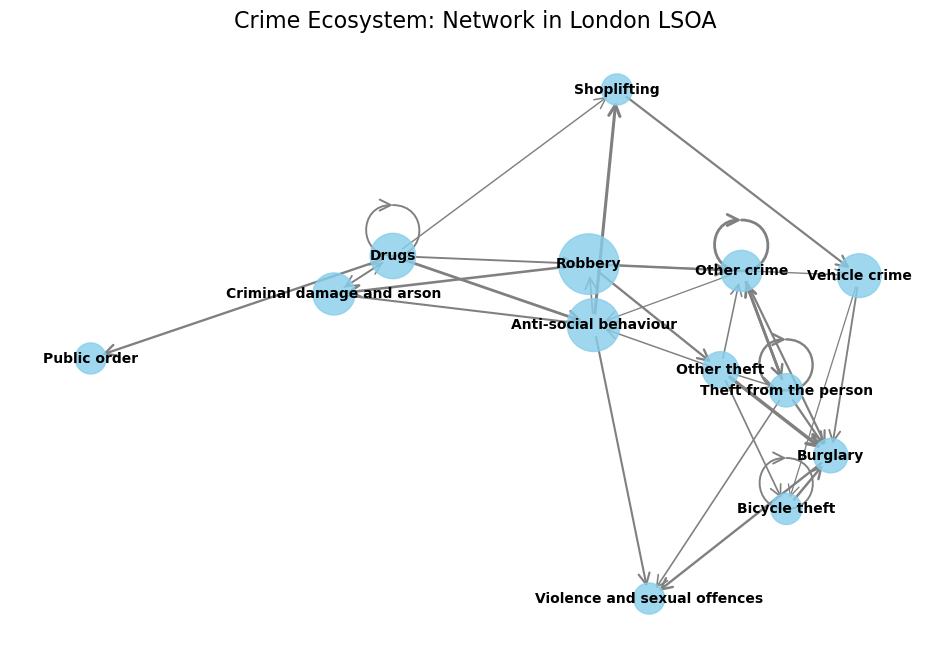


--- Top Brokerage Crimes (Betweenness Centrality) ---
Robbery: 0.2803
Anti-social behaviour: 0.1894
Drugs: 0.1136
Vehicle crime: 0.0985
Criminal damage and arson: 0.0833
Other crime: 0.0758
Other theft: 0.0379
Burglary: 0.0227
Theft from the person: 0.0152
Shoplifting: 0.0000
Bicycle theft: 0.0000
Violence and sexual offences: 0.0000
Public order: 0.0000


In [16]:
G = nx.DiGraph()

for index, row in strongEdges.iterrows():
    source_node = row['Crime 2'].replace('_prevM', '')
    target_node = row['Crime 1']
    weight = row['Correlation']

    G.add_edge(source_node, target_node, weight=weight)


# Betweenness Centrality
# This calculates how often a crime acts as a "bridge"
centrality = nx.betweenness_centrality(G, weight='weight')

# Visualize
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5, seed=42)

# Node size based on Betweenness Centrality (brokers bigger)
node_sizes = [v * 5000 + 500 for v in centrality.values()]

# Edge thickness based on the correlation
edge_weights = [G[u][v]['weight'] * 3 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8)
nx.draw_networkx_edges(G, pos, width=edge_weights, arrowstyle='->', arrowsize=20, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title("Crime Ecosystem: Network in London LSOA", fontsize=16)
plt.axis('off')
plt.show()

# 6. Print the mathematical brokers
print("\n--- Top Brokerage Crimes (Betweenness Centrality) ---")
for crime, score in sorted(centrality.items(), key=lambda item: item[1], reverse=True):
    print(f"{crime}: {score:.4f}")